# **Imports**

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

from utils import set_seed
from earthscape_dataset import *
from sgmapnet import *
from focal_loss import *
from training_utils import *

import datetime
import json
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import torch.optim as optim

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.metrics import average_precision_score, hamming_loss, accuracy_score


In [36]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

# **Parameters**

In [2]:

# set seed for reproducibility
seed = 111
set_seed(seed)


# dictionary of modality name & list of unique file extensions
modality_configs = {
    'dem': {
        'extensions': ['dem.tif']
        }, 
    # 'nhd': {
    #     'extensions': ['nhd.tif']
    #     },
    # 'ep': {
    #     'extensions': ['ep_5x5.tif', 'ep_11x11.tif', 'ep_21x21.tif', 'ep_51x51.tif', 'ep_101x101.tif']
    #     }, 
    }


# get normalization parameters...
stats_path = r'../../data/warren/image_stats.csv'
modality_configs = get_norm_stats(stats_path, modality_configs)


# list of directories containing patch data
patch_dirs = [r'../../data/warren/patches_warren', 
              r'../../data/howevalley/patches_hv', 
              r'../../data/sonora/patches_sonora']


# get list of patch IDs & pytroch dataset...
# training set
train_patch_path = r'../../models/splits/indomain_val.geojson'
gdf = gpd.read_file(train_patch_path)
train_patch_ids = gdf['patch_id'].to_list()
train_dataset = EarthScape_Dataset(train_patch_ids[:40], patch_dirs, modality_configs, augment=True)


# validation set
val_patch_path = r'../../models/splits/indomain_val.geojson'
gdf = gpd.read_file(val_patch_path)
val_patch_ids = gdf['patch_id'].to_list()
val_dataset = EarthScape_Dataset(val_patch_ids[:40], patch_dirs, modality_configs, augment=True)

# indomain test set
test_patch_path = r'../../models/splits/indomain_test.geojson'
gdf = gpd.read_file(test_patch_path)
test_patch_ids = gdf['patch_id'].to_list()
test_dataset = EarthScape_Dataset(test_patch_ids[:40], patch_dirs, modality_configs, augment=True)

# cross domain test set
cross_test_patch_path = r'../../models/splits/crossdomain_test.geojson'
gdf = gpd.read_file(cross_test_patch_path)
cross_test_patch_ids = gdf['patch_id'].to_list()
cross_test_dataset = EarthScape_Dataset(cross_test_patch_ids[:40], patch_dirs, modality_configs, augment=True)


# dataloader & model settings...
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batch_size = 4
num_epochs = 5

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
cross_test_loader = DataLoader(cross_test_dataset, batch_size=batch_size, shuffle=True, drop_last=True)



encoder = 'vit'
model = Multilabel_Classification(modality_configs, encoder).to(device)
optimizer = optim.Adam(model.parameters())


# focal loss...
reduction = 'sum'
gamma = 2.0
alpha = 0.25
alpha = torch.tensor(alpha, dtype=torch.float32).view(1, -1).to(device)
criterion = FocalLoss(alpha=alpha, gamma=gamma, reduction=reduction).to(device)


# create output directory
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
modality_str = '_'.join(list(modality_configs.keys()))
model_name = f"{encoder}_{modality_str}_{timestamp}"
output_dir = f"../../models/classification/{model_name}"
if not os.path.isdir(output_dir):
    os.makedirs(output_dir)
else:
    print('Directory already exists...')


# log metadata
training_log(model_name, output_dir, seed,
             train_patch_path, val_patch_path, test_patch_path, cross_test_patch_path,
             modality_configs, 
             batch_size, num_epochs, optimizer, criterion, model)

# **Dataloader Example**

In [3]:
# extract example
example = next(iter(val_loader))

# print data report
for modality in example.keys():
    print(modality)
    print(f"{type(example[modality])}  |  {example[modality].dtype}  |  {example[modality].shape}  |  {example[modality].min()}  |  {example[modality].max()}")

label
<class 'torch.Tensor'>  |  torch.float32  |  torch.Size([4, 7])  |  0.0  |  1.0
dem
<class 'torch.Tensor'>  |  torch.float32  |  torch.Size([4, 1, 256, 256])  |  -8.306511878967285  |  0.7769823670387268


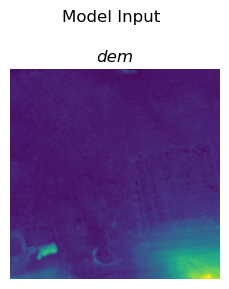

In [4]:

# extract total number of channels to plot...
num_channels = 0
for k,v in example.items():
    if not 'label' in k:
        num_channels += v.shape[1]

# define number of columns & rows...
ncols = min(4, num_channels)
nrows = (num_channels // ncols) + 1

# setup figure...
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3*ncols, 3*nrows))
ax = ax.ravel()

# plot channels separately...
idx = 0
for k,v in example.items():
    if 'label' in k:
        label = v.detach().numpy()[0]
        fig.suptitle(f"Model Input")
    else:
        v_sample = v.detach().numpy()[0]
        for c in range(v_sample.shape[0]):
            img = v_sample[c]
            min_val = img.min()
            max_val = img.max()
            img = (img - min_val) / (max_val - min_val + 1e-8)
            ax[idx].imshow(img)
            ax[idx].set_axis_off()
            ax[idx].set_title(k, style='italic')
            idx += 1

# remove any extra subplot axes...
for j in range(idx, len(ax)):
    fig.delaxes(ax[j])

plt.show()


# **Training**

In [5]:
df_train = train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs, output_dir)

Epoch 1
TRAINING   -- Loss: 1.0672  |  Accuracy: 74.64%  |  Time: 0.12 mins.
VALIDATION -- Loss: 0.9905  |  Accuracy: 71.43%  |  Time: 0.03 mins.
New best model saved!


Epoch 2
TRAINING   -- Loss: 0.9582  |  Accuracy: 73.21%  |  Time: 0.12 mins.
VALIDATION -- Loss: 0.8134  |  Accuracy: 73.57%  |  Time: 0.05 mins.
New best model saved!


Epoch 3
TRAINING   -- Loss: 0.8391  |  Accuracy: 73.93%  |  Time: 0.12 mins.
VALIDATION -- Loss: 0.7637  |  Accuracy: 80.00%  |  Time: 0.03 mins.
New best model saved!


Epoch 4
TRAINING   -- Loss: 0.7781  |  Accuracy: 79.64%  |  Time: 0.12 mins.
VALIDATION -- Loss: 0.7095  |  Accuracy: 80.36%  |  Time: 0.03 mins.
New best model saved!


Epoch 5
TRAINING   -- Loss: 0.7335  |  Accuracy: 76.43%  |  Time: 0.12 mins.
VALIDATION -- Loss: 0.6715  |  Accuracy: 80.36%  |  Time: 0.03 mins.
New best model saved!




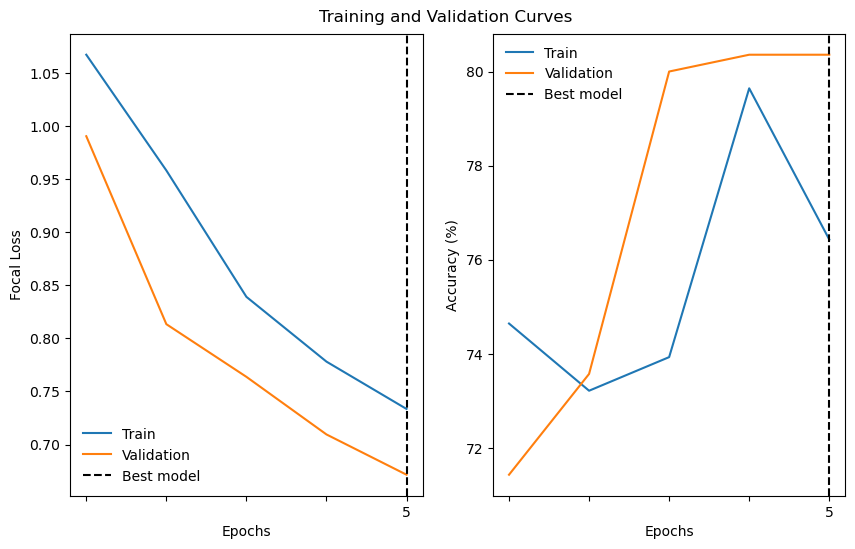

In [6]:
fig = plot_training_curves(df_train, output_dir)

fig.savefig(f"{output_dir}/training_curves.png", dpi=300, bbox_inches='tight', pad_inches=0)

# **Validation Set Tuning**

In [39]:
model_path = glob.glob(f"{output_dir}/best_loss_epoch*.pth")[0]

state_dict = torch.load(model_path, map_location=device, weights_only=False)

model.load_state_dict(state_dict)


# calculate optimal thresholds from validation set
optimal_thresholds = calculate_optimal_thresholds(model, val_loader, device)

# **In-Domain Inference**

## *Global Performance*

In [40]:

probabilities, targets = test_model(model, test_loader, device)

df = calculate_global_metrics(targets, probabilities, thresholds=optimal_thresholds)

df.to_csv(f"{output_dir}/indomain_global_metrics.csv", index=False)

df.head()

,Precision,Recall,F1,AUC,mAP,Accuracy,Precision (Wt.),Recall (Wt.),F1 (Wt.),AUC (Wt.),mAP (Wt.),Accuracy (Micro),Accuarcy,Accuarcy (Micro)
0,0.473135,0.68478,0.506197,NaN,0.517895,NaN,0.708629,0.794872,0.740802,0.673865,0.774891,NaN,0.546429,0.546429


## *Per Class Performance*

In [41]:

df = pd.DataFrame(columns=['Class', 'True', 'Predicted', 'Precision', 'Recall', 'F1', 'AUROC', 'AP', 'Accuracy'])

for idx, (unit, thresh) in enumerate(zip(['af1', 'Qal', 'Qaf', 'Qat', 'Qc', 'Qca', 'Qr'], optimal_thresholds)):

    df.loc[idx, 'Class'] = unit + f" ({str(round(thresh, 2))})"

    preds = probabilities[:, idx].numpy()
    targs = targets[:, idx].numpy()
    binary_preds = (preds >= thresh)

    df.loc[idx, 'True'] = int(targs.sum())
    df.loc[idx, 'Predicted'] = (preds >= thresh).sum()
    df.loc[idx, 'Accuracy'] = accuracy_score(targs, binary_preds)
    df.loc[idx, 'Precision'] = precision_score(targs, binary_preds)
    df.loc[idx, 'Recall'] = recall_score(targs, binary_preds)
    df.loc[idx, 'F1'] = f1_score(targs, binary_preds)
    df.loc[idx, 'AUC'] = roc_auc_score(targs, preds)
    df.loc[idx, 'AP'] = average_precision_score(targs, preds)

df.to_csv(f"{output_dir}/indomain_class_metrics.csv", index=False)

df.head(10)


,Class,True,Predicted,Precision,Recall,F1,AUROC,AP,Accuracy,AUC
0,af1 (0.36),15,26,0.346154,0.6,0.439024,NaN,0.350498,0.425,0.424000
1,Qal (0.45),29,34,0.705882,0.827586,0.761905,NaN,0.882156,0.625,0.677116
2,Qaf (0.01),1,39,0.025641,1.0,0.05,NaN,0.083333,0.05,0.717949
3,Qat (0.3),0,22,0.0,0.0,0.0,NaN,0.0,0.45,NaN
4,Qc (0.47),21,25,0.76,0.904762,0.826087,NaN,0.800686,0.8,0.817043
5,Qca (0.47),15,16,0.5625,0.6,0.580645,NaN,0.542129,0.675,0.581333
6,Qr (0.61),36,34,0.911765,0.861111,0.885714,NaN,0.96646,0.8,0.729167


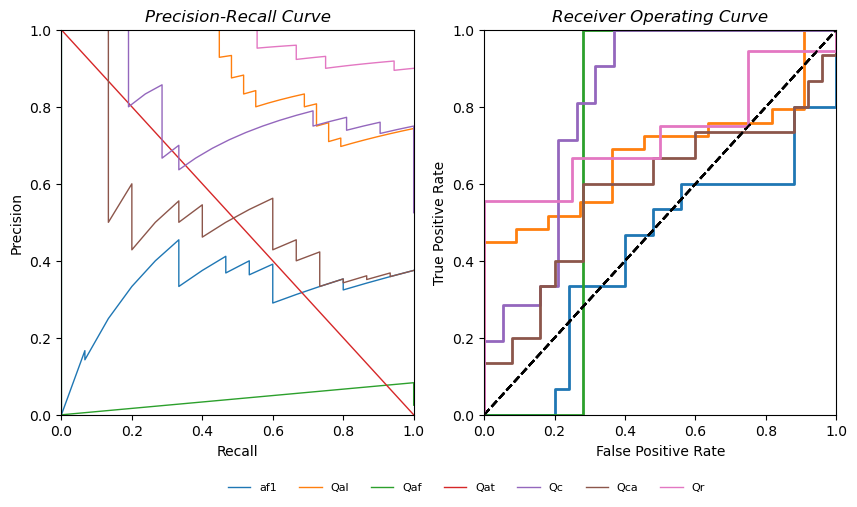

In [42]:
class_cols = ['af1', 'Qal', 'Qaf', 'Qat', 'Qc', 'Qca', 'Qr']

fig = plot_label_pr_roc_curves(targets, probabilities, class_cols)

fig.savefig(f"{output_dir}/indomain_pr_curves.jpg")

# **Cross-Domain Inference**

## *Global Performance*

In [37]:
probabilities, targets = test_model(model, cross_test_loader, device)

df = calculate_global_metrics(targets, probabilities, thresholds=optimal_thresholds)

df.to_csv(f"{output_dir}/crossdomain_global_metrics.csv", index=False)

df.head()

,Precision,Recall,F1,AUC,mAP,Accuracy,Precision (Wt.),Recall (Wt.),F1 (Wt.),AUC (Wt.),mAP (Wt.),Accuracy (Micro),Accuarcy,Accuarcy (Micro)
0,0.292857,0.571429,0.361345,NaN,0.532781,NaN,0.615934,0.901099,0.690368,NaN,0.754385,NaN,0.642857,0.642857


## *Per Class Performance*

In [38]:
df = pd.DataFrame(columns=['Class', 'True', 'Predicted', 'Precision', 'Recall', 'F1', 'AUROC', 'AP', 'Accuracy'])

for idx, (unit, thresh) in enumerate(zip(['af1', 'Qal', 'Qaf', 'Qat', 'Qc', 'Qca', 'Qr'], optimal_thresholds)):

    df.loc[idx, 'Class'] = unit + f" ({str(round(thresh, 2))})"

    preds = probabilities[:, idx].numpy()
    targs = targets[:, idx].numpy()
    binary_preds = (preds >= thresh)

    df.loc[idx, 'True'] = int(targs.sum())
    df.loc[idx, 'Predicted'] = (preds >= thresh).sum()
    df.loc[idx, 'Accuracy'] = accuracy_score(targs, binary_preds)
    df.loc[idx, 'Precision'] = precision_score(targs, binary_preds)
    df.loc[idx, 'Recall'] = recall_score(targs, binary_preds)
    df.loc[idx, 'F1'] = f1_score(targs, binary_preds)
    df.loc[idx, 'AUC'] = roc_auc_score(targs, preds)
    df.loc[idx, 'AP'] = average_precision_score(targs, preds)

df.to_csv(f"{output_dir}/crossdomain_class_metrics.csv", index=False)

df.head(10)

,Class,True,Predicted,Precision,Recall,F1,AUROC,AP,Accuracy,AUC
0,af1 (0.36),11,40,0.275,1.0,0.431373,NaN,0.63762,0.275,0.730408
1,Qal (0.45),20,40,0.5,1.0,0.666667,NaN,0.527782,0.5,0.525000
2,Qaf (0.01),0,13,0.0,0.0,0.0,NaN,0.0,0.675,NaN
3,Qat (0.3),3,0,0.0,0.0,0.0,NaN,0.7,0.925,0.963964
4,Qc (0.47),11,40,0.275,1.0,0.431373,NaN,0.759047,0.275,0.849530
5,Qca (0.47),6,0,0.0,0.0,0.0,NaN,0.105015,0.85,0.181373
6,Qr (0.61),40,40,1.0,1.0,1.0,NaN,1.0,1.0,NaN


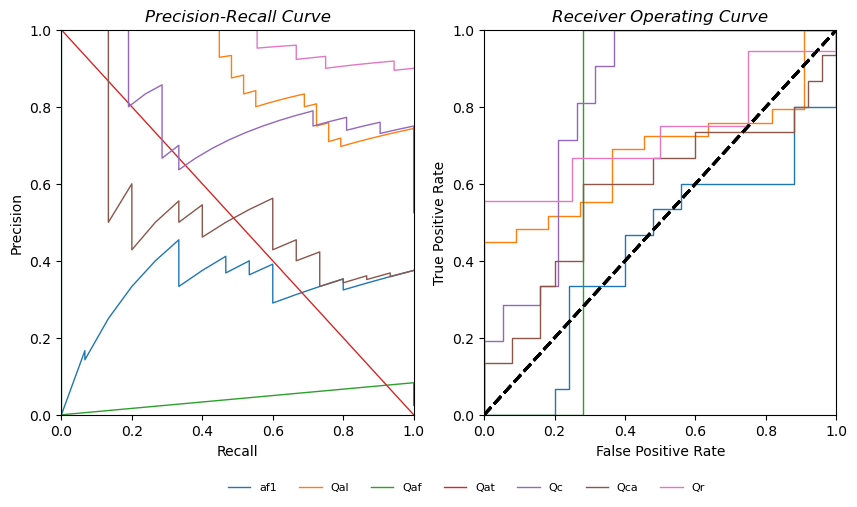

In [46]:
class_cols = ['af1', 'Qal', 'Qaf', 'Qat', 'Qc', 'Qca', 'Qr']

fig = plot_label_pr_roc_curves(targets, probabilities, class_cols)

fig.savefig(f"{output_dir}/crossdomain_pr_curves.jpg")